In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
import joblib

from imblearn.over_sampling import SMOTE

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
!git clone https://github.com/somepago/saint.git
%cd saint


Cloning into 'saint'...
remote: Enumerating objects: 70, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 70 (delta 21), reused 19 (delta 19), pack-reused 35 (from 1)
Receiving objects: 100% (70/70), 209.36 KiB | 6.34 MiB/s, done.
Resolving deltas: 100% (34/34), done.
/content/saint


In [3]:
import torch

import sys
sys.path.append("/content/saint")


In [4]:
from models.model import RowColTransformer




In [5]:

from google.colab import files
import pandas as pd
import numpy as np

uploaded = files.upload()

Saving EnviroBirth PreBEnvBD Dataset-Driven Prediction.csv to EnviroBirth PreBEnvBD Dataset-Driven Prediction.csv


In [6]:

df = pd.read_csv(list(uploaded.keys())[0])

print("Shape:", df.shape)
print("Columns:", df.columns)
df.head()

Shape: (73000, 59)
Columns: Index(['Address', 'Latitude', 'Longitude', 'SO2', 'NO2', 'CO', 'O3', 'PM2.5',
       'PM10', 'CASEID', 'BIDX', 'Birth_Order', 'Multiple_Birth',
       'Preceding_Birth_Interval', 'Succeeding_Birth_Interval',
       'Gestational_Duration', 'Mother_Age', 'Education', 'Wealth_Index',
       'Drinking_Water_Source', 'Toilet_Type', 'Electricity', 'Cooking_Fuel',
       'Usual_Residents', 'Sleeping_Rooms', 'Place_of_Delivery',
       'Multiple_Birth.1', 'Child_Alive', 'Age_at_Death_Days',
       'Age_at_Death_Months', 'Gestation_Months', 'Pregnancy_Duration',
       'Birth_Size_Reported', 'Birth_Weight_Reported', 'Mother_Age.1',
       'Mother_Height', 'Mother_Weight', 'Mother_BMI', 'Delivery_Assistance',
       'Csection_Delivery', 'Iron_Supplement', 'BP_Checked', 'Urine_Test',
       'Blood_Test', 'Ultrasound', 'Weight_Measured', 'Height_Measured',
       'Stomach_Exam', 'Fetal_heartbeat', 'Blood_Pressure_Test',
       'Cooking_Location', 'Separate_Kitchen', 'Ha

,Address,Latitude,Longitude,SO2,NO2,CO,O3,PM2.5,PM10,CASEID,...,Blood_Pressure_Test,Cooking_Location,Separate_Kitchen,Has_Mosquito_Net,Number_Mosquito_Nets,Children_Using_Nets,Rainfall,Humidity,Temperature,Preterm
0,"Uttara, Dhaka, Bangladesh,",23.820612,90.421011,0.04,0.059,1.2,0.0525,57,73,0100 1 4,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,78.0,20.1,0
1,"Jatrabari, Dhaka, Bangladesh,",23.820612,90.421011,0.04,0.058,1.2,0.0525,59,71,0100 11 1,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,79.0,21.0,1
2,"Kuril Bishow Road, Dhaka, Bangladesh,",23.820612,90.421011,0.04,0.056,1.2,0.0525,59,70,0102 3 2,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,82.0,20.1,0
3,"Mohakhali, Dhaka, Bangladesh,",23.820612,90.421011,0.04,0.056,1.2,0.0525,58,70,0102 8 1,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,73.0,21.0,0
4,"Dhanmondi, Dhaka, Bangladesh)",23.820612,90.421011,0.03,0.051,1.2,0.0525,61,69,0104 4 2,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,67.0,20.3,0


In [7]:
env_features = ["SO2","NO2","CO","O3","PM2.5","PM10","Rainfall","Humidity","Temperature"]
maternal_features = ["Mother_Age","Mother_Height","Mother_Weight","Mother_BMI","Gestation_Months","Birth_Weight_Reported"]
household_features = ["Education","Wealth_Index","Drinking_Water_Source","Toilet_Type","Cooking_Fuel","Cooking_Location","Separate_Kitchen","Electricity","Has_Mosquito_Net"]
drop_cols = ["CASEID","BIDX","Address","Latitude","Longitude"]
features = env_features + maternal_features + household_features


In [8]:
selected = [c for c in (env_features + maternal_features + household_features) if c in df.columns]
print("Selected features (will use):", selected)
target = "Preterm"
if target not in df.columns:
    raise ValueError(f"Target column '{target}' not found in df.columns")

Selected features (will use): ['SO2', 'NO2', 'CO', 'O3', 'PM2.5', 'PM10', 'Rainfall', 'Humidity', 'Temperature', 'Mother_Age', 'Mother_Height', 'Mother_Weight', 'Mother_BMI', 'Gestation_Months', 'Birth_Weight_Reported', 'Education', 'Wealth_Index', 'Drinking_Water_Source', 'Toilet_Type', 'Cooking_Fuel', 'Cooking_Location', 'Separate_Kitchen', 'Electricity', 'Has_Mosquito_Net']


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
import numpy as np

X = df[selected].copy()
y = df[target].copy()

if y.dtype == 'object' or y.dtype.name == 'category':
    tmp = y.astype(str).str.strip().str.lower()
    if set(tmp.unique()).issubset({'yes','no','y','n'}):
        y = tmp.map({'yes':1,'y':1,'no':0,'n':0})
    else:
        le_target = LabelEncoder()
        y = le_target.fit_transform(y.astype(str))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

numeric_feats = X_train.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_feats = [c for c in selected if c not in numeric_feats]

empty_numeric = [c for c in numeric_feats if X_train[c].isna().all()]
if empty_numeric:
    print("Dropping fully empty numeric columns:", empty_numeric)
    X_train = X_train.drop(columns=empty_numeric)
    X_test = X_test.drop(columns=empty_numeric)
    numeric_feats = [c for c in numeric_feats if c not in empty_numeric]

num_imputer = SimpleImputer(strategy='median')
X_train[numeric_feats] = num_imputer.fit_transform(X_train[numeric_feats])
X_test[numeric_feats] = num_imputer.transform(X_test[numeric_feats])

if categorical_feats:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    X_train[categorical_feats] = cat_imputer.fit_transform(X_train[categorical_feats])
    X_test[categorical_feats] = cat_imputer.transform(X_test[categorical_feats])
    X_train_cat = X_train[categorical_feats].apply(lambda x: x.astype('category').cat.codes)
    X_test_cat = X_test[categorical_feats].apply(lambda x: x.astype('category').cat.codes)
else:
    X_train_cat = np.empty((X_train.shape[0], 0))
    X_test_cat = np.empty((X_test.shape[0], 0))
    print("No categorical features detected, skipping categorical imputation/encoding.")

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("After SMOTE, train shape:", X_train_res.shape)
print("Target distribution:", np.bincount(y_train_res))

scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train_res[numeric_feats])
X_test_num = scaler.transform(X_test[numeric_feats])

X_train_proc = np.concatenate([X_train_num, X_train_cat if X_train_cat.size else np.empty((X_train_num.shape[0],0))], axis=1)
X_test_proc = np.concatenate([X_test_num, X_test_cat if X_test_cat.size else np.empty((X_test_num.shape[0],0))], axis=1)

print("Processed Train Shape:", X_train_proc.shape)

if categorical_feats:
    cat_idxs = [X_train_res.columns.get_loc(col) for col in categorical_feats]
    cat_dims = [X_train_res[col].nunique() for col in categorical_feats]
else:
    cat_idxs = []
    cat_dims = []

print("Categorical Indexes:", cat_idxs)
print("Categorical Cardinalities:", cat_dims)



Dropping fully empty numeric columns: ['Birth_Weight_Reported']
No categorical features detected, skipping categorical imputation/encoding.
After SMOTE, train shape: (107734, 23)
Target distribution: [53867 53867]
Processed Train Shape: (107734, 23)
Categorical Indexes: []
Categorical Cardinalities: []


In [10]:

X_train_num = scaler.fit_transform(X_train_res[numeric_feats])
X_test_num = scaler.transform(X_test[numeric_feats])

if categorical_feats:
    X_train_cat = X_train_res[categorical_feats].apply(lambda x: x.astype('category').cat.codes).to_numpy()
    X_test_cat = X_test[categorical_feats].apply(lambda x: x.astype('category').cat.codes).to_numpy()
else:
    X_train_cat = np.empty((X_train_num.shape[0],0))
    X_test_cat = np.empty((X_test_num.shape[0],0))

X_train_proc = np.concatenate([X_train_num, X_train_cat], axis=1)
X_test_proc = np.concatenate([X_test_num, X_test_cat], axis=1)


In [11]:
num_features = X_train_proc.shape[1]
nfeats = num_features


In [12]:

import torch
import torch.nn as nn

def forward(self, x=None, x_cont=None, mask=None):

    if x is None and x_cont is not None:
        x = x_cont
    elif x is not None and x_cont is not None:
        x = torch.cat((x, x_cont), dim=1)

    batch_size, n, dim = x.shape

    if mask is not None:
        mask_emb = self.mask_embed(mask)
        x = x + mask_emb

    for layer in self.layers:
        x = layer(x)

    return x


In [13]:
from models.model import RowColTransformer


In [14]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [15]:

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

class RowColTransformer(nn.Module):
    def __init__(self, num_tokens=None, dim=32, nfeats=None,
                 depth=2, heads=4, dim_head=32,
                 attn_dropout=0.1, ff_dropout=0.1,
                 style='col'):
        super().__init__()
        self.dim = dim
        self.nfeats = nfeats
        self.style = style


        self.embedding = nn.Identity()


        self.layers = nn.ModuleList([
            nn.Sequential(
                nn.LayerNorm(dim),
                nn.Linear(dim, dim),
                nn.ReLU(),
                nn.Dropout(ff_dropout)
            ) for _ in range(depth)
        ])


        self.head = nn.Linear(dim, 2)

    def forward(self, x=None, x_cont=None, mask=None):

        if x is None and x_cont is not None:
            x = x_cont
        elif x is not None and x_cont is not None:
            x = torch.cat((x, x_cont), dim=1)

        batch_size, n, dim = x.shape


        for layer in self.layers:
            x = layer(x)


        x = x.mean(dim=1)


        out = self.head(x)
        return out


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_proc)
X_test_scaled = scaler.transform(X_test_proc)


X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_res.values, dtype=torch.long)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)


train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


embedding_dim = 32
cont_embed = nn.Linear(X_train_tensor.shape[1], embedding_dim)


saint_model = RowColTransformer(dim=embedding_dim, nfeats=embedding_dim, depth=6, heads=8)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(list(saint_model.parameters()) + list(cont_embed.parameters()), lr=1e-3)


num_epochs = 20
history = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}

for epoch in range(num_epochs):

    saint_model.train()
    train_loss = 0
    y_true_train = []
    y_pred_train = []

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()


        X_embedded = cont_embed(X_batch).unsqueeze(1)


        outputs = saint_model(x_cont=X_embedded)


        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()


        train_loss += loss.item() * X_batch.size(0)
        y_true_train.extend(y_batch.tolist())
        y_pred_train.extend(torch.argmax(outputs, dim=1).tolist())

    train_loss /= len(train_loader.dataset)
    train_acc = accuracy_score(y_true_train, y_pred_train)


    saint_model.eval()
    val_loss = 0
    y_true_val = []
    y_pred_val = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_embedded = cont_embed(X_batch).unsqueeze(1)
            outputs = saint_model(x_cont=X_embedded)
            loss = criterion(outputs, y_batch)

            val_loss += loss.item() * X_batch.size(0)
            y_true_val.extend(y_batch.tolist())
            y_pred_val.extend(torch.argmax(outputs, dim=1).tolist())

    val_loss /= len(test_loader.dataset)
    val_acc = accuracy_score(y_true_val, y_pred_val)


    history['loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['accuracy'].append(train_acc)
    history['val_accuracy'].append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} - "
          f"loss: {train_loss:.4f}, acc: {train_acc:.4f}, "
          f"val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f}")


Epoch 1/20 - loss: 0.5807, acc: 0.6720, val_loss: 0.5220, val_acc: 0.6444
Epoch 2/20 - loss: 0.5332, acc: 0.7095, val_loss: 0.5718, val_acc: 0.6427
Epoch 3/20 - loss: 0.5098, acc: 0.7264, val_loss: 0.4555, val_acc: 0.7863
Epoch 4/20 - loss: 0.4955, acc: 0.7360, val_loss: 0.4823, val_acc: 0.7612
Epoch 5/20 - loss: 0.4877, acc: 0.7417, val_loss: 0.5092, val_acc: 0.7152
Epoch 6/20 - loss: 0.4802, acc: 0.7477, val_loss: 0.5000, val_acc: 0.7134
Epoch 7/20 - loss: 0.4782, acc: 0.7484, val_loss: 0.4970, val_acc: 0.6868
Epoch 8/20 - loss: 0.4734, acc: 0.7513, val_loss: 0.5123, val_acc: 0.7242
Epoch 9/20 - loss: 0.4719, acc: 0.7530, val_loss: 0.5423, val_acc: 0.7042
Epoch 10/20 - loss: 0.4690, acc: 0.7550, val_loss: 0.5715, val_acc: 0.6523
Epoch 11/20 - loss: 0.4663, acc: 0.7557, val_loss: 0.4532, val_acc: 0.7904
Epoch 12/20 - loss: 0.4640, acc: 0.7590, val_loss: 0.5202, val_acc: 0.7308
Epoch 13/20 - loss: 0.4633, acc: 0.7594, val_loss: 0.4904, val_acc: 0.7334
Epoch 14/20 - loss: 0.4605, acc: 0

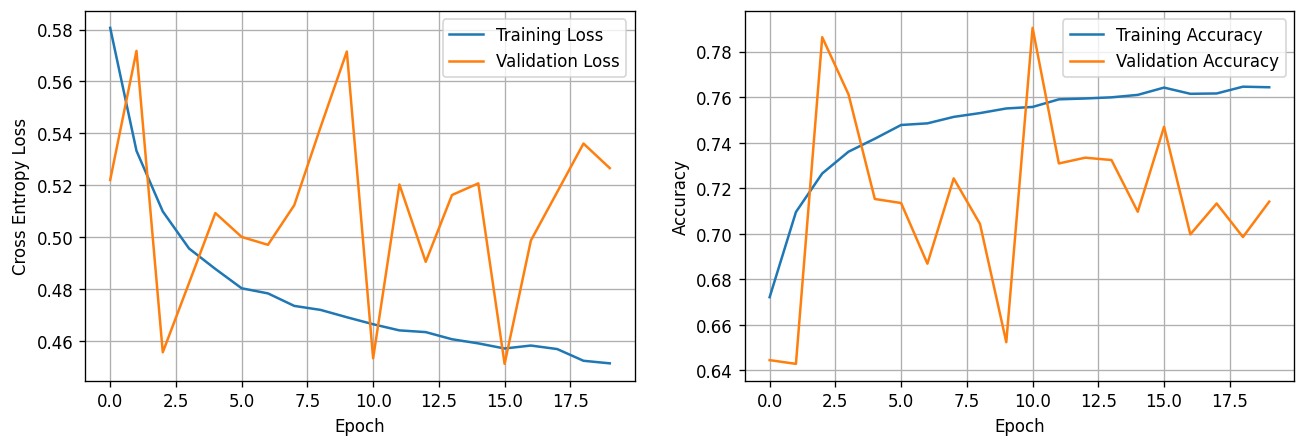

In [16]:
import matplotlib.pyplot as plt

def plot_training_curves(history_dict, savepath='/content/drive/MyDrive/SAINT_LossVsAccuracy.pdf'):
    plt.figure(figsize=(13, 4), dpi=120)


    plt.subplot(1, 2, 1)
    plt.plot(history_dict['loss'], label='Training Loss')
    plt.plot(history_dict['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Cross Entropy Loss')
    plt.grid()
    plt.legend()


    plt.subplot(1, 2, 2)
    plt.plot(history_dict['accuracy'], label='Training Accuracy')
    plt.plot(history_dict['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid()
    plt.legend()

    plt.savefig(savepath, bbox_inches='tight')
    plt.show()

plot_training_curves(history)


Test Accuracy: 0.714041095890411

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.74      0.83     13467
           1       0.12      0.44      0.19      1133

    accuracy                           0.71     14600
   macro avg       0.53      0.59      0.51     14600
weighted avg       0.88      0.71      0.78     14600



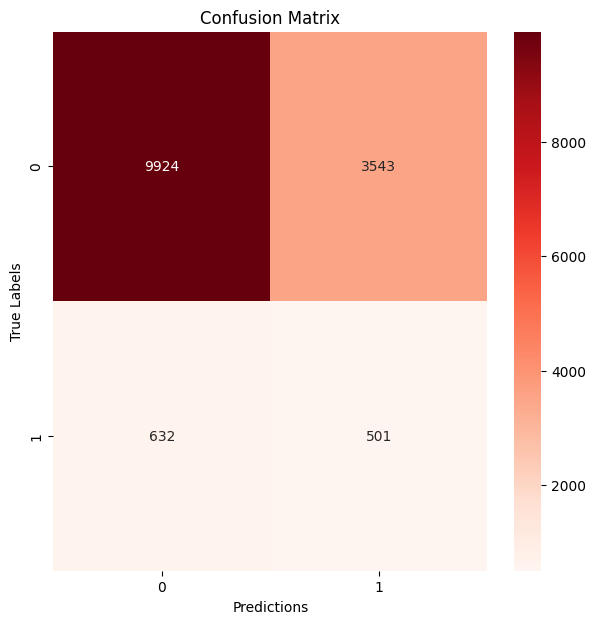

In [17]:

saint_model.eval()
y_pred_test = []
y_true_test = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_embedded = cont_embed(X_batch).unsqueeze(1)
        outputs = saint_model(x_cont=X_embedded)
        y_pred_test.extend(torch.argmax(outputs, dim=1).tolist())
        y_true_test.extend(y_batch.tolist())

from sklearn.metrics import accuracy_score, classification_report
print("Test Accuracy:", accuracy_score(y_true_test, y_pred_test))
print("\nClassification Report:\n", classification_report(y_true_test, y_pred_test))


import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7), dpi=100)
sns.heatmap(confusion_matrix(y_true_test, y_pred_test), fmt='d', annot=True, cmap='Reds')
plt.xlabel('Predictions')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.savefig('/content/drive/MyDrive/SAINT_ConfusionMatrix.pdf', bbox_inches='tight')
plt.show()


Embedding এ ফিচার সংখ্যা: 23
Dataset এ ফিচার সংখ্যা: 23

👉 SAINT embedding এ শীর্ষ ফিচারসমূহ:
                  Feature  Importance
14              Education    0.181133
22       Has_Mosquito_Net    0.178296
18           Cooking_Fuel    0.134552
0                     SO2    0.066309
1                     NO2    0.064859
13       Gestation_Months    0.053343
19       Cooking_Location    0.042660
20       Separate_Kitchen    0.038781
3                      O3    0.034299
8             Temperature    0.033847
17            Toilet_Type    0.032925
2                      CO    0.024921
15           Wealth_Index    0.018740
16  Drinking_Water_Source    0.017219
11          Mother_Weight    0.016358
21            Electricity    0.014016
12             Mother_BMI    0.012260
7                Humidity    0.008416
4                   PM2.5    0.008298
10          Mother_Height    0.007090
9              Mother_Age    0.005813
5                    PM10    0.003051
6                Rainfall    0.0

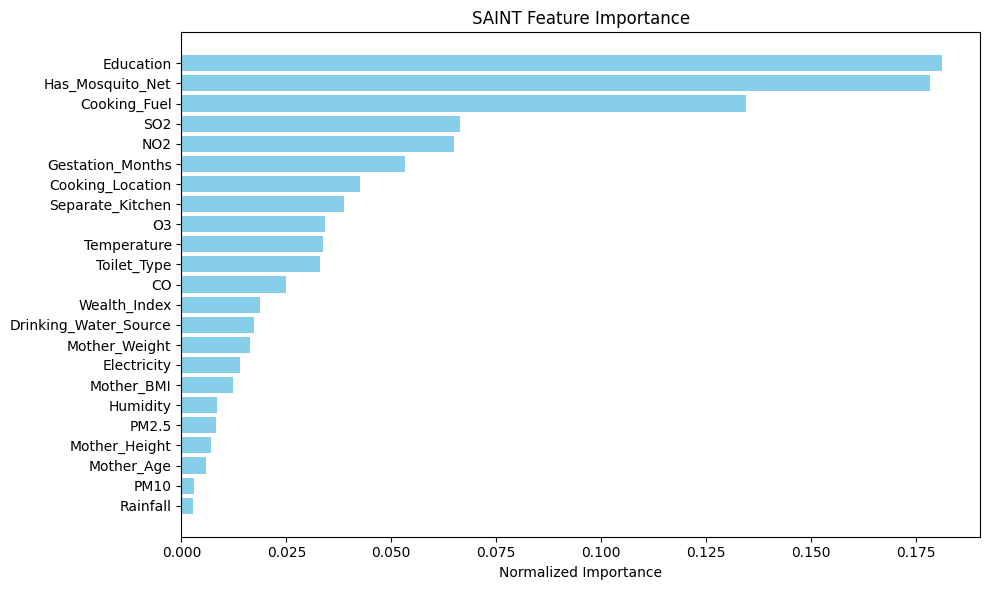

In [18]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

feature_names_for_importance = X_train.columns.tolist()

num_features = cont_embed.in_features
print(f"Embedding এ ফিচার সংখ্যা: {num_features}")
print(f"Dataset এ ফিচার সংখ্যা: {len(feature_names_for_importance)}")

assert len(feature_names_for_importance) == num_features, \
       f"Mismatch! model={num_features}, dataset={len(feature_names_for_importance)}"

feature_weights = cont_embed.weight.detach().cpu().numpy()
feature_importance = (feature_weights**2).sum(axis=0)
feature_importance = feature_importance / feature_importance.sum()

importance_df = pd.DataFrame({
    'Feature': feature_names_for_importance,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)

print("\n👉 SAINT embedding এ শীর্ষ ফিচারসমূহ:")
print(importance_df)

plt.figure(figsize=(10,6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.gca().invert_yaxis()
plt.xlabel('Normalized Importance')
plt.title('SAINT Feature Importance')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/SAINT_FeatureImportance.pdf', bbox_inches='tight')
plt.show()

importance_df.head(10).to_csv('/content/drive/MyDrive/SAINT_Top10_Features.csv', index=False)


In [19]:
import inspect
import torch
from torch.utils.data import DataLoader

print("--- 1. SAINT Model Signature ---")
try:
    sig = inspect.signature(saint_model.forward)
    print(f"The model expects these inputs: {sig}")
except Exception as e:
    print(f"Could not read model signature: {e}")

print("\n--- 2. Memory & Data Check ---")
vars_to_check = ['X_test_t', 'X_test', 'test_dataloader', 'test_loader', 'val_loader']

for var_name in vars_to_check:
    if var_name in globals() or var_name in locals():
        var = eval(var_name)
        print(f"\n[✓] Found '{var_name}'!")

        if hasattr(var, 'shape'):
            print(f"    Shape: {var.shape}")

        elif isinstance(var, DataLoader):
            print(f"    Type: PyTorch DataLoader")
            try:
                # Grab exactly one batch to see what it looks like
                batch = next(iter(var))
                if isinstance(batch, (list, tuple)):
                    print(f"    Batch contains {len(batch)} items:")
                    for i, item in enumerate(batch):
                        if hasattr(item, 'shape'):
                            print(f"      Item {i} shape: {item.shape}")
                        else:
                            print(f"      Item {i} type: {type(item)}")
                elif isinstance(batch, dict):
                    print(f"    Batch is a dictionary with keys: {list(batch.keys())}")
                    for k, v in batch.items():
                        if hasattr(v, 'shape'):
                            print(f"      Key '{k}' shape: {v.shape}")
            except Exception as e:
                print(f"    Could not read a batch from loader: {e}")
        else:
            print(f"    Type: {type(var)}")
    else:
        print(f"[X] '{var_name}' is NOT defined in memory.")

--- 1. SAINT Model Signature ---
The model expects these inputs: (x=None, x_cont=None, mask=None)

--- 2. Memory & Data Check ---
[X] 'X_test_t' is NOT defined in memory.

[✓] Found 'X_test'!
    Shape: (14600, 23)
[X] 'test_dataloader' is NOT defined in memory.

[✓] Found 'test_loader'!
    Type: PyTorch DataLoader
    Batch contains 2 items:
      Item 0 shape: torch.Size([32, 23])
      Item 1 shape: torch.Size([32])
[X] 'val_loader' is NOT defined in memory.


In [20]:
import torch
import numpy as np

# Put BOTH the model and the embedding layer in evaluation mode
saint_model.eval()
cont_embed.eval()

y_pred_proba_list = []
y_test_list = []

print("Extracting predictions using cont_embed and saint_model...")

# Ensure we are using the correct device (CPU or GPU)
device = next(saint_model.parameters()).device

with torch.no_grad():
    for X_batch, y_batch in test_loader:

        # Move batches to device
        X_batch = X_batch.to(device)

        # ---------------------------------------------------------
        # THE FIX: Apply the exact same transformations as your training loop
        # ---------------------------------------------------------
        X_embedded = cont_embed(X_batch).unsqueeze(1)
        outputs = saint_model(x_cont=X_embedded)

        # Since your head is nn.Linear(dim, 2), we use Softmax and grab the probabilities for class 1
        probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()

        y_pred_proba_list.extend(probs.tolist())
        y_test_list.extend(y_batch.numpy().tolist())

# Convert to flat numpy arrays for sklearn metrics
y_pred_proba_saint = np.array(y_pred_proba_list)
y_test_saint = np.array(y_test_list)

# Create hard predictions (threshold at 0.5)
y_pred_saint = (y_pred_proba_saint >= 0.5).astype(int)

print("--- SAINT Output Debug ---")
print(f"y_test_saint shape: {y_test_saint.shape}")
print(f"y_pred_proba shape: {y_pred_proba_saint.shape}")
print(f"y_pred shape: {y_pred_saint.shape}")
print("Extraction complete! Ready for evaluation.")

Extracting predictions using cont_embed and saint_model...
--- SAINT Output Debug ---
y_test_saint shape: (14600,)
y_pred_proba shape: (14600,)
y_pred shape: (14600,)
Extraction complete! Ready for evaluation.


SAINT Model - Matthews Correlation Coefficient (MCC): 0.1071
SAINT Model - Log Loss: 0.5265
--------------------------------------------------


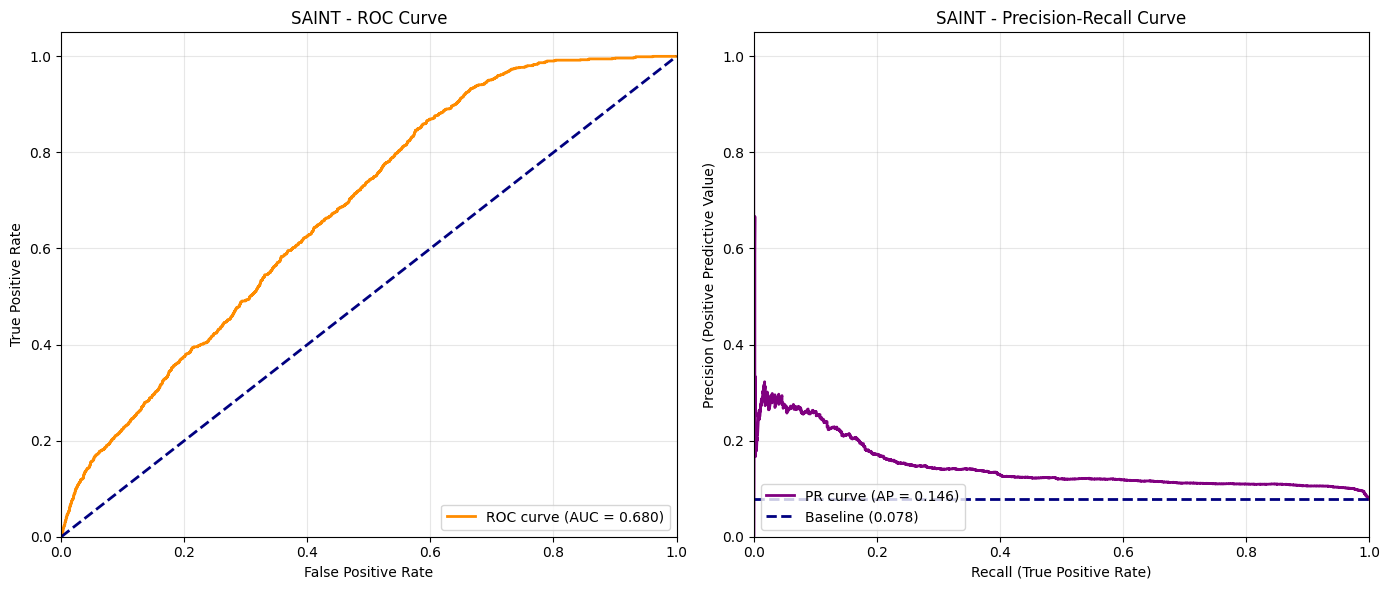

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    matthews_corrcoef,
    log_loss,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

# ---------------------------------------------------------
# 1. Calculate and Print MCC and Log Loss
# ---------------------------------------------------------
mcc = matthews_corrcoef(y_test_saint, y_pred_saint)
ll = log_loss(y_test_saint, y_pred_proba_saint)

print(f"SAINT Model - Matthews Correlation Coefficient (MCC): {mcc:.4f}")
print(f"SAINT Model - Log Loss: {ll:.4f}")
print("-" * 50)

# ---------------------------------------------------------
# 2. Calculate Curve Data
# ---------------------------------------------------------
# ROC Curve data
fpr, tpr, roc_thresholds = roc_curve(y_test_saint, y_pred_proba_saint)
roc_auc = auc(fpr, tpr)

# Precision-Recall Curve data
precision, recall, pr_thresholds = precision_recall_curve(y_test_saint, y_pred_proba_saint)
pr_auc = average_precision_score(y_test_saint, y_pred_proba_saint)

# ---------------------------------------------------------
# 3. Plot the Curves
# ---------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: ROC Curve
ax[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
ax[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[0].set_xlim([0.0, 1.0])
ax[0].set_ylim([0.0, 1.05])
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].set_title('SAINT - ROC Curve')
ax[0].legend(loc="lower right")
ax[0].grid(alpha=0.3)

# Plot 2: Precision-Recall Curve
ax[1].plot(recall, precision, color='purple', lw=2, label=f'PR curve (AP = {pr_auc:.3f})')
baseline = y_test_saint.sum() / len(y_test_saint)
ax[1].plot([0, 1], [baseline, baseline], color='navy', lw=2, linestyle='--', label=f'Baseline ({baseline:.3f})')
ax[1].set_xlim([0.0, 1.0])
ax[1].set_ylim([0.0, 1.05])
ax[1].set_xlabel('Recall (True Positive Rate)')
ax[1].set_ylabel('Precision (Positive Predictive Value)')
ax[1].set_title('SAINT - Precision-Recall Curve')
ax[1].legend(loc="lower left")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()